## Carbon Stock Estimation — Ludhiana District


##  Folder Path

In [1]:
import os

FOLDER = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"

if not os.path.isdir(FOLDER):
    raise FileNotFoundError(f"Folder not found: {FOLDER}")

REQUIRED_FILES = [
    "Above_ground_data_geom.csv",
    "Below_Ground_Data_geom.csv",
    "ndvi_monthly_ludhiana_jun24_may25.csv",
    "AGD_for_all_grids_geom.csv",
    "BGD_for_all_grids(GEOM).csv",
    "ndvi_monthly_ludhiana_all_66790.csv",
]
missing = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(FOLDER, f))]
if missing:
    print("WARNING — these files are missing:", missing)
else:
    print("All required files found ✓")

print("Folder:", FOLDER)
print("Contents:", sorted(os.listdir(FOLDER)))

All required files found ✓
Folder: C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks
Contents: ['AGD_for_all_grids_geom.csv', 'Above_ground_data_geom.csv', 'BGD_for_all_grids(GEOM).csv', 'Below_Ground_Data_geom.csv', 'above_ground_clean.csv', 'ag_carbon_per_cell.csv', 'below_ground_clean.csv', 'bg_carbon_per_cell.csv', 'carbon_all_66790_final.csv', 'carbon_final_report.txt', 'carbon_project', 'carbon_stock_pipeline_FIXED.ipynb', 'district_carbon_summary_66790.txt', 'evaluation_report.txt', 'model_ag_rf.pkl', 'model_ag_xgb.pkl', 'model_bg_rf.pkl', 'model_bg_xgb.pkl', 'ndvi_monthly_ludhiana_all_66790.csv', 'ndvi_monthly_ludhiana_jun24_may25.csv', 'plot1_actual_vs_predicted.png', 'plot2_residuals.png', 'plot3_feature_importance.png', 'plot4_error_distribution.png', 'plot5_carbon_distribution.png', 'plot6_carbon_summary.png']


## Step 3 — Data Cleaning + NDVI Merge

In [2]:
import os
import pandas as pd
import numpy as np

FOLDER    = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
NPP_COL   = "Agricultur"
SOC_COL   = "SOC_mean"
NDVI_COLS = ["NDVI_Jun24","NDVI_Jul24","NDVI_Aug24","NDVI_Sep24",
             "NDVI_Oct24","NDVI_Nov24","NDVI_Dec24","NDVI_Jan25",
             "NDVI_Feb25","NDVI_Mar25","NDVI_Apr25","NDVI_May25"]

# Load raw geometry files
ag   = pd.read_csv(os.path.join(FOLDER, "Above_ground_data_geom.csv"))
bg   = pd.read_csv(os.path.join(FOLDER, "Below_Ground_Data_geom.csv"))
ndvi = pd.read_csv(os.path.join(FOLDER, "ndvi_monthly_ludhiana_jun24_may25.csv"))
print("AG:", ag.shape, "  BG:", bg.shape, "  NDVI:", ndvi.shape)

# Prepare NDVI — drop coordinate cols, deduplicate, take mean per cell
ndvi = ndvi.drop(columns=["longitude","latitude"], errors="ignore")
ndvi = ndvi.groupby("Grid_ID")[NDVI_COLS].mean().reset_index()

# Merge NDVI into AG
ag = ag.merge(ndvi, on="Grid_ID", how="left")
for col in NDVI_COLS:
    ag[col] = ag[col].fillna(ag[col].median())

# Drop geometry and ID columns (not needed for training)
ag = ag.drop(columns=["WKT","Grid_ID"])
bg = bg.drop(columns=["WKT","Grid_ID"])

# Fix NPP nulls and negatives
ag[NPP_COL] = ag[NPP_COL].fillna(0).clip(lower=0)

# Fill remaining nulls with median per column
for col in [c for c in ag.columns if c != NPP_COL]:
    ag[col] = ag[col].fillna(ag[col].median())
for col in [c for c in bg.columns if c != SOC_COL]:
    bg[col] = bg[col].fillna(bg[col].median())

# Move target column to the last position
ag = ag[[c for c in ag.columns if c != NPP_COL] + [NPP_COL]]

# Save cleaned files
ag.to_csv(os.path.join(FOLDER, "above_ground_clean.csv"), index=False)
bg.to_csv(os.path.join(FOLDER, "below_ground_clean.csv"), index=False)
print("above_ground_clean.csv saved:", ag.shape)
print("below_ground_clean.csv saved:", bg.shape)
print("STEP 3 COMPLETE")

AG: (20000, 14)   BG: (20000, 9)   NDVI: (20000, 15)
above_ground_clean.csv saved: (20000, 24)
below_ground_clean.csv saved: (20000, 7)
STEP 3 COMPLETE


## Step 4 — Train / Test Split

In [3]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

FOLDER       = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
NPP_COL      = "Agricultur"
SOC_COL      = "SOC_mean"
RANDOM_STATE = 42

# Load cleaned files
ag = pd.read_csv(os.path.join(FOLDER, "above_ground_clean.csv"))
bg = pd.read_csv(os.path.join(FOLDER, "below_ground_clean.csv"))
print("AG:", ag.shape, "  BG:", bg.shape)

# AG: filter to agricultural cells only, separate zero-NPP cells
ag_agri    = ag[ag["agri_class"] == 1].copy()
ag_nonzero = ag_agri[ag_agri[NPP_COL] > 0].copy()
ag_zero    = ag_agri[ag_agri[NPP_COL] == 0].copy()
print("Genuine NPP cells:", len(ag_nonzero), "  Zero-NPP cells:", len(ag_zero))

# AG split 80/20 — features = all columns except agri_class and target
AG_FEATURES = [c for c in ag_nonzero.columns if c not in ["agri_class", NPP_COL]]
X_ag = ag_nonzero[AG_FEATURES]
y_ag = ag_nonzero[NPP_COL]
X_ag_train, X_ag_test, y_ag_train, y_ag_test = train_test_split(
    X_ag, y_ag, test_size=0.2, random_state=RANDOM_STATE)
print("AG Train:", X_ag_train.shape, "  Test:", X_ag_test.shape)

# BG split: fixed 16000 train / 4000 test
BG_FEATURES = [c for c in bg.columns if c != SOC_COL]
X_bg = bg[BG_FEATURES]
y_bg = bg[SOC_COL]
X_bg_train, X_bg_test, y_bg_train, y_bg_test = train_test_split(
    X_bg, y_bg, train_size=16000, test_size=4000, random_state=RANDOM_STATE)
print("BG Train:", X_bg_train.shape, "  Test:", X_bg_test.shape)

# Save all split files
X_ag_train.to_csv(os.path.join(FOLDER, "ag_X_train.csv"),        index=False)
X_ag_test.to_csv( os.path.join(FOLDER, "ag_X_test.csv"),         index=False)
y_ag_train.to_csv(os.path.join(FOLDER, "ag_y_train.csv"),        index=False, header=True)
y_ag_test.to_csv( os.path.join(FOLDER, "ag_y_test.csv"),         index=False, header=True)
X_bg_train.to_csv(os.path.join(FOLDER, "bg_X_train.csv"),        index=False)
X_bg_test.to_csv( os.path.join(FOLDER, "bg_X_test.csv"),         index=False)
y_bg_train.to_csv(os.path.join(FOLDER, "bg_y_train.csv"),        index=False, header=True)
y_bg_test.to_csv( os.path.join(FOLDER, "bg_y_test.csv"),         index=False, header=True)
ag_zero.to_csv(   os.path.join(FOLDER, "ag_zero_npp_cells.csv"), index=False)
print("All split files saved. STEP 4 COMPLETE")

AG: (20000, 24)   BG: (20000, 7)
Genuine NPP cells: 12602   Zero-NPP cells: 3650
AG Train: (10081, 22)   Test: (2521, 22)
BG Train: (16000, 6)   Test: (4000, 6)
All split files saved. STEP 4 COMPLETE


## Step 5 — Train Models

In [4]:
import os, pickle, time
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import r2_score

try:
    from xgboost import XGBRegressor
    USE_XGB = True;  XGB_LABEL = "XGBoost"
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False; XGB_LABEL = "GradientBoosting"
    print("XGBoost not found, using GradientBoosting instead")

FOLDER       = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
RANDOM_STATE = 42

X_ag_train = pd.read_csv(os.path.join(FOLDER, "ag_X_train.csv"))
y_ag_train = pd.read_csv(os.path.join(FOLDER, "ag_y_train.csv")).squeeze()
X_bg_train = pd.read_csv(os.path.join(FOLDER, "bg_X_train.csv"))
y_bg_train = pd.read_csv(os.path.join(FOLDER, "bg_y_train.csv")).squeeze()
print("AG train:", X_ag_train.shape, "  BG train:", X_bg_train.shape)

RF_PARAMS = dict(n_estimators=300, min_samples_split=4, min_samples_leaf=2,
                 n_jobs=-1, random_state=RANDOM_STATE)
if USE_XGB:
    XGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
else:
    XGB_PARAMS = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                      subsample=0.8, random_state=RANDOM_STATE)

def train(label, model, X, y):
    print("Training", label, "...", end="", flush=True)
    t = time.time()
    model.fit(X, y)
    print(f"  {time.time()-t:.1f}s   train R2={r2_score(y, np.maximum(model.predict(X), 0)):.4f}")
    return model

rf_ag  = train("RF  AG",          RandomForestRegressor(**RF_PARAMS), X_ag_train, y_ag_train)
xgb_ag = train(f"{XGB_LABEL} AG", XGBRegressor(**XGB_PARAMS) if USE_XGB else GradientBoostingRegressor(**XGB_PARAMS), X_ag_train, y_ag_train)
rf_bg  = train("RF  BG",          RandomForestRegressor(**RF_PARAMS), X_bg_train, y_bg_train)
xgb_bg = train(f"{XGB_LABEL} BG", XGBRegressor(**XGB_PARAMS) if USE_XGB else GradientBoostingRegressor(**XGB_PARAMS), X_bg_train, y_bg_train)

with open(os.path.join(FOLDER, "model_ag_rf.pkl"),  "wb") as f: pickle.dump(rf_ag,  f)
with open(os.path.join(FOLDER, "model_ag_xgb.pkl"), "wb") as f: pickle.dump(xgb_ag, f)
with open(os.path.join(FOLDER, "model_bg_rf.pkl"),  "wb") as f: pickle.dump(rf_bg,  f)
with open(os.path.join(FOLDER, "model_bg_xgb.pkl"), "wb") as f: pickle.dump(xgb_bg, f)
print("All 4 models saved. STEP 5 COMPLETE")

AG train: (10081, 22)   BG train: (16000, 6)
Training RF  AG ...  1.9s   train R2=0.9088
Training XGBoost AG ...  0.4s   train R2=0.8208
Training RF  BG ...  0.7s   train R2=0.9928
Training XGBoost BG ...  0.2s   train R2=0.9755
All 4 models saved. STEP 5 COMPLETE


## Step 6 — Evaluate Models

Model                    Target   R2       RMSE       MAE
------------------------------------------------------------
Random Forest            NPP     0.5426    448.597    314.795
XGBoost/GradBoost        NPP     0.5346    452.490    318.675
Random Forest            SOC     0.9665      1.392      1.012
XGBoost/GradBoost        SOC     0.9648      1.428      1.058
Best AG: Random Forest  R2=0.5426
Best BG: Random Forest  R2=0.9665


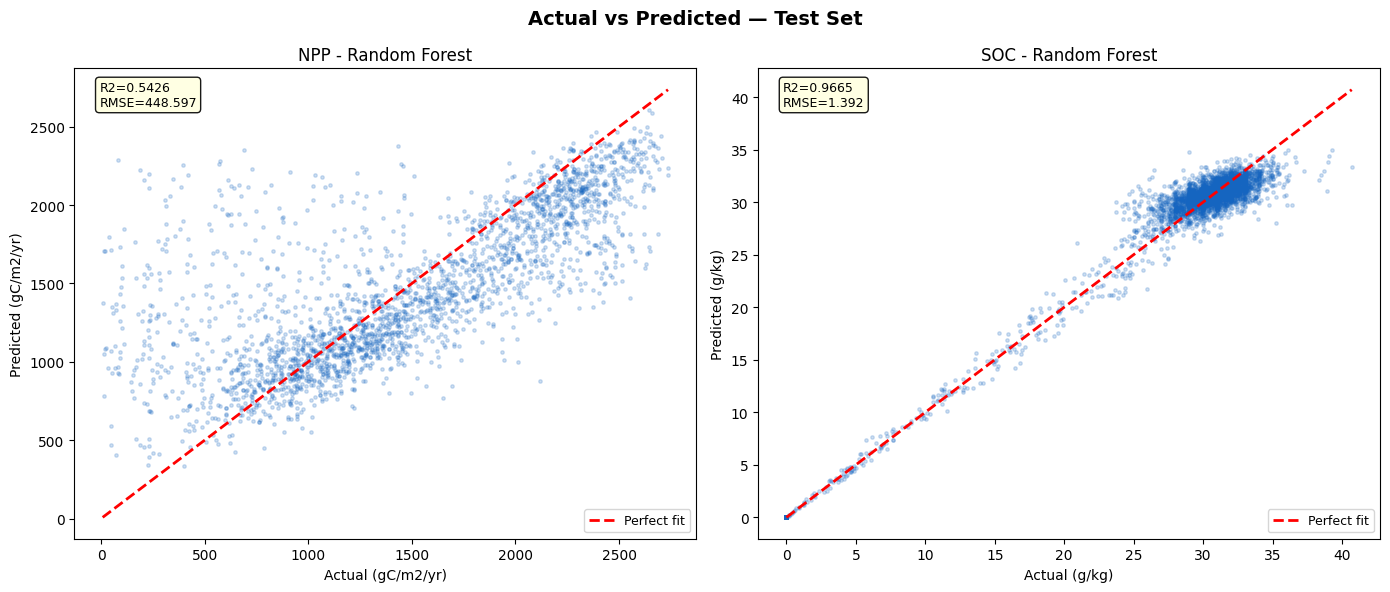

plot1 saved


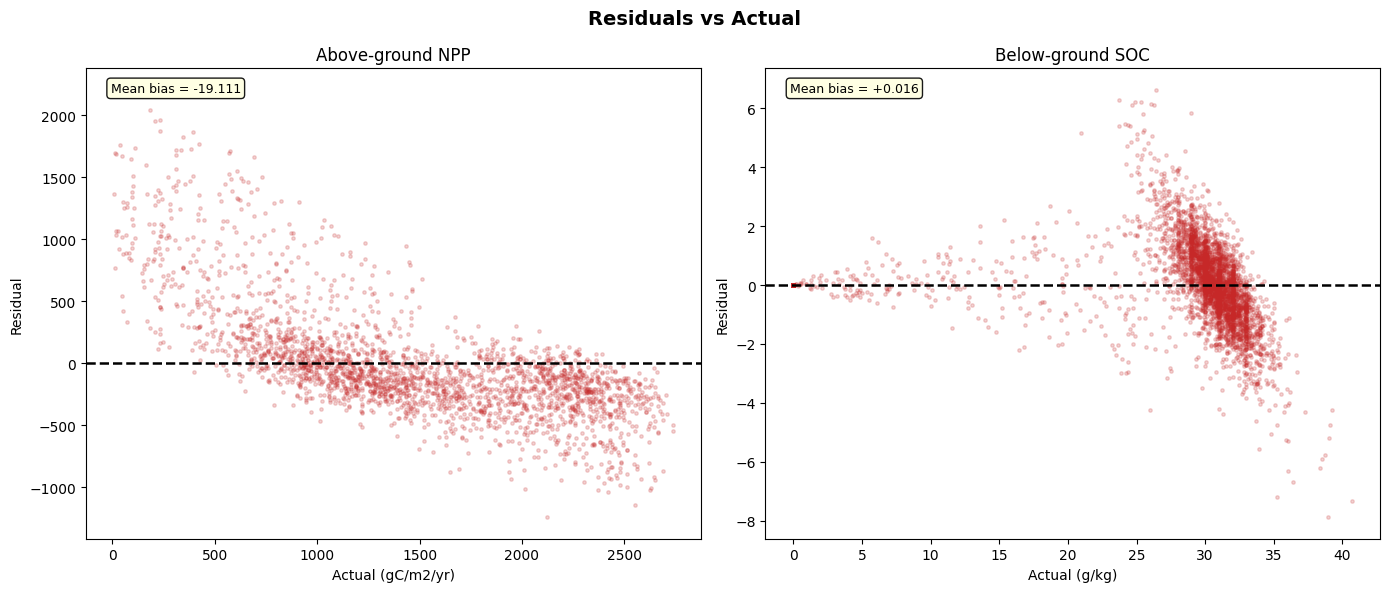

plot2 saved


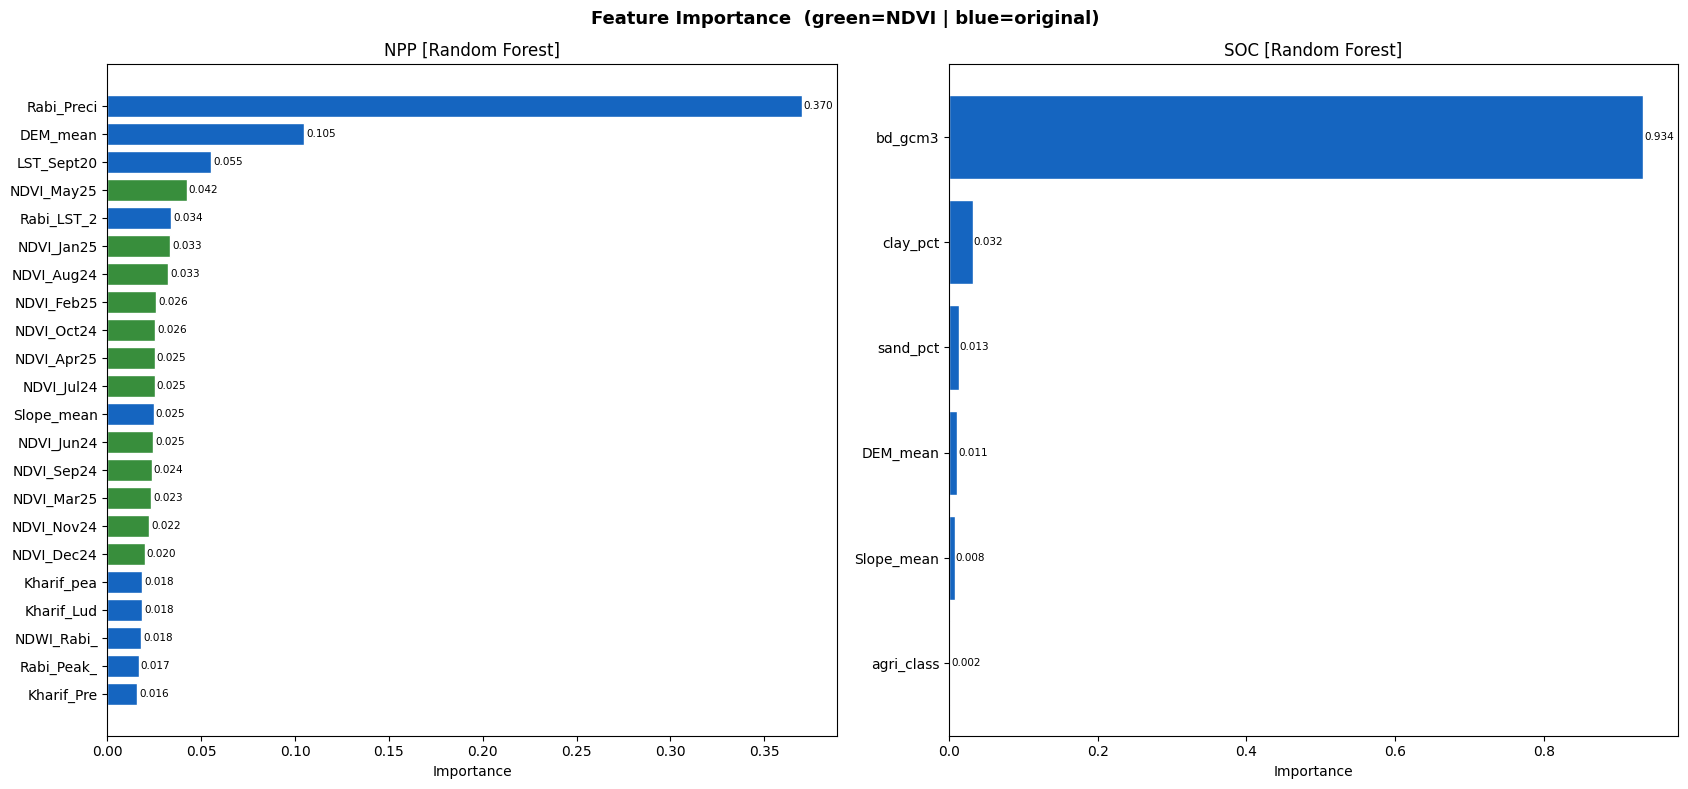

plot3 saved


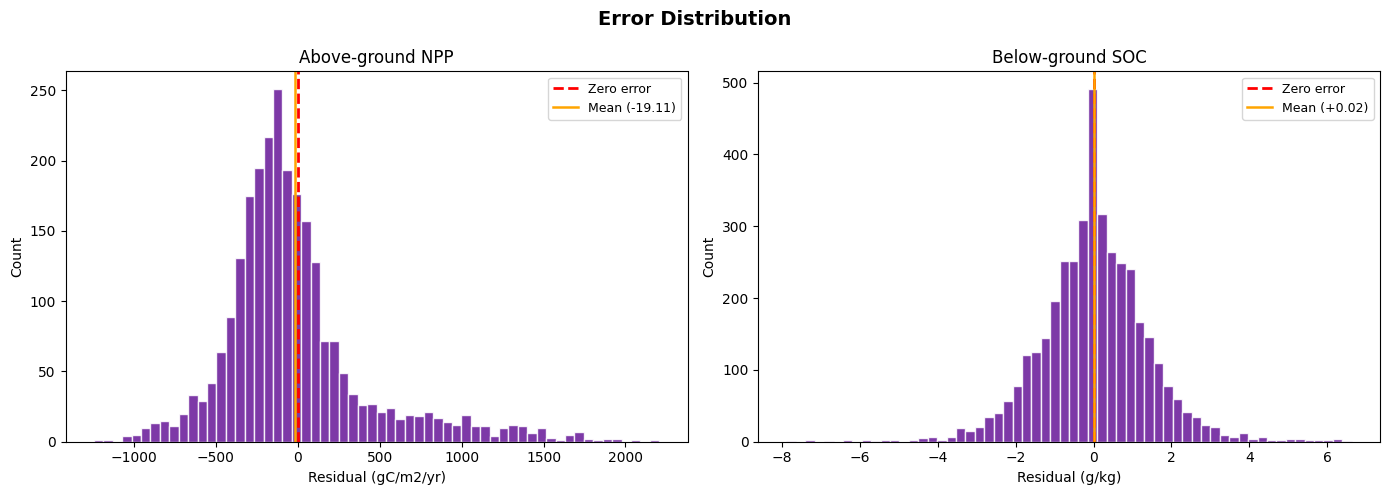

plot4 saved
evaluation_report.txt saved. STEP 6 COMPLETE


In [5]:
import os, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

FOLDER    = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
NDVI_COLS = ["NDVI_Jun24","NDVI_Jul24","NDVI_Aug24","NDVI_Sep24",
             "NDVI_Oct24","NDVI_Nov24","NDVI_Dec24","NDVI_Jan25",
             "NDVI_Feb25","NDVI_Mar25","NDVI_Apr25","NDVI_May25"]

X_ag_test = pd.read_csv(os.path.join(FOLDER, "ag_X_test.csv"))
y_ag_test = pd.read_csv(os.path.join(FOLDER, "ag_y_test.csv")).squeeze()
X_bg_test = pd.read_csv(os.path.join(FOLDER, "bg_X_test.csv"))
y_bg_test = pd.read_csv(os.path.join(FOLDER, "bg_y_test.csv")).squeeze()
with open(os.path.join(FOLDER, "model_ag_rf.pkl"),  "rb") as f: rf_ag  = pickle.load(f)
with open(os.path.join(FOLDER, "model_ag_xgb.pkl"), "rb") as f: xgb_ag = pickle.load(f)
with open(os.path.join(FOLDER, "model_bg_rf.pkl"),  "rb") as f: rf_bg  = pickle.load(f)
with open(os.path.join(FOLDER, "model_bg_xgb.pkl"), "rb") as f: xgb_bg = pickle.load(f)

pred_rf_ag  = np.maximum(rf_ag.predict(X_ag_test),  0)
pred_xgb_ag = np.maximum(xgb_ag.predict(X_ag_test), 0)
pred_rf_bg  = np.maximum(rf_bg.predict(X_bg_test),  0)
pred_xgb_bg = np.maximum(xgb_bg.predict(X_bg_test), 0)

print(f"{'Model':<24} Target   R2       RMSE       MAE")
print("-"*60)
results = []
for label, y_true, y_pred, target in [
    ("Random Forest",     y_ag_test, pred_rf_ag,  "NPP"),
    ("XGBoost/GradBoost", y_ag_test, pred_xgb_ag, "NPP"),
    ("Random Forest",     y_bg_test, pred_rf_bg,  "SOC"),
    ("XGBoost/GradBoost", y_bg_test, pred_xgb_bg, "SOC")]:
    r2   = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    results.append({"label":label,"target":target,"R2":r2,"RMSE":rmse,"MAE":mae})
    print(f"{label:<24} {target:<6}  {r2:.4f}   {rmse:>8.3f}   {mae:>8.3f}")

best_ag      = max([r for r in results if r["target"]=="NPP"], key=lambda x: x["R2"])
best_bg      = max([r for r in results if r["target"]=="SOC"], key=lambda x: x["R2"])
pred_ag_best = pred_rf_ag  if best_ag["label"]=="Random Forest" else pred_xgb_ag
pred_bg_best = pred_rf_bg  if best_bg["label"]=="Random Forest" else pred_xgb_bg
best_ag_mdl  = rf_ag       if best_ag["label"]=="Random Forest" else xgb_ag
best_bg_mdl  = rf_bg       if best_bg["label"]=="Random Forest" else xgb_bg
print(f"Best AG: {best_ag['label']}  R2={best_ag['R2']:.4f}")
print(f"Best BG: {best_bg['label']}  R2={best_bg['R2']:.4f}")

# Plot 1 — Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted — Test Set", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, m, unit in [
    (axes[0], y_ag_test, pred_ag_best, best_ag, "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, best_bg, "g/kg")]:
    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color="#1565C0", rasterized=True)
    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title(f"{m['target']} - {m['label']}")
    ax.legend(fontsize=9)
    ax.text(0.04, 0.92, f"R2={m['R2']:.4f}\nRMSE={m['RMSE']:.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, "plot1_actual_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("plot1 saved")

# Plot 2 — Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Residuals vs Actual", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, title, unit in [
    (axes[0], y_ag_test, pred_ag_best, "Above-ground NPP", "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, "Below-ground SOC", "g/kg")]:
    res = y_pred - y_true
    ax.scatter(y_true, res, alpha=0.2, s=6, color="#C62828", rasterized=True)
    ax.axhline(0, color="black", lw=1.8, linestyle="--")
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel("Residual")
    ax.set_title(title)
    ax.text(0.04, 0.95, f"Mean bias = {float(res.mean()):+.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, "plot2_residuals.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("plot2 saved")

# Plot 3 — Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("Feature Importance  (green=NDVI | blue=original)", fontsize=13, fontweight="bold")
for ax, model, feat_names, title in [
    (axes[0], best_ag_mdl, list(X_ag_test.columns), f"NPP [{best_ag['label']}]"),
    (axes[1], best_bg_mdl, list(X_bg_test.columns), f"SOC [{best_bg['label']}]")]:
    imp = model.feature_importances_; idx = np.argsort(imp)
    colors = ["#388E3C" if feat_names[i] in NDVI_COLS else "#1565C0" for i in idx]
    ax.barh(np.array(feat_names)[idx], imp[idx], color=colors, edgecolor="white")
    ax.set_xlabel("Importance"); ax.set_title(title)
    for i, v in enumerate(imp[idx]):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=7.5)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, "plot3_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("plot3 saved")

# Plot 4 — Error Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Distribution", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, title, unit in [
    (axes[0], y_ag_test, pred_ag_best, "Above-ground NPP", "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, "Below-ground SOC", "g/kg")]:
    res = y_pred - y_true
    ax.hist(res, bins=60, color="#6A1B9A", edgecolor="white", alpha=0.87)
    ax.axvline(0, color="red", lw=2, linestyle="--", label="Zero error")
    ax.axvline(float(res.mean()), color="orange", lw=1.8, linestyle="-",
               label=f"Mean ({float(res.mean()):+.2f})")
    ax.set_xlabel(f"Residual ({unit})"); ax.set_ylabel("Count"); ax.set_title(title)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, "plot4_error_distribution.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("plot4 saved")

report = "EVALUATION REPORT\n" + "="*40 + "\n"
for r in results:
    report += f"{r['label']} {r['target']}  R2={r['R2']:.4f}  RMSE={r['RMSE']:.3f}  MAE={r['MAE']:.3f}\n"
with open(os.path.join(FOLDER, "evaluation_report.txt"), "w", encoding="utf-8") as f:
    f.write(report)
print("evaluation_report.txt saved. STEP 6 COMPLETE")

## Step 7 — Carbon Stock Calculation (20k cells)

Above-ground Carbon : 1.6678 million tC  (3.1%)
Below-ground Carbon : 52.5602 million tC  (96.9%)
TOTAL Carbon Stock  : 54.2280 million tC


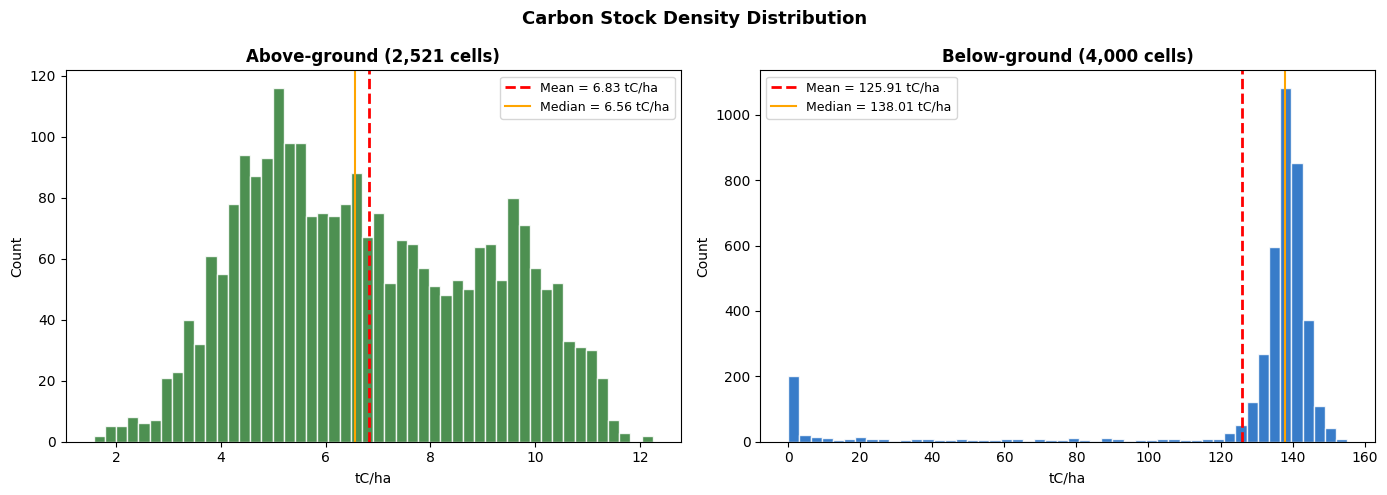

plot5 saved


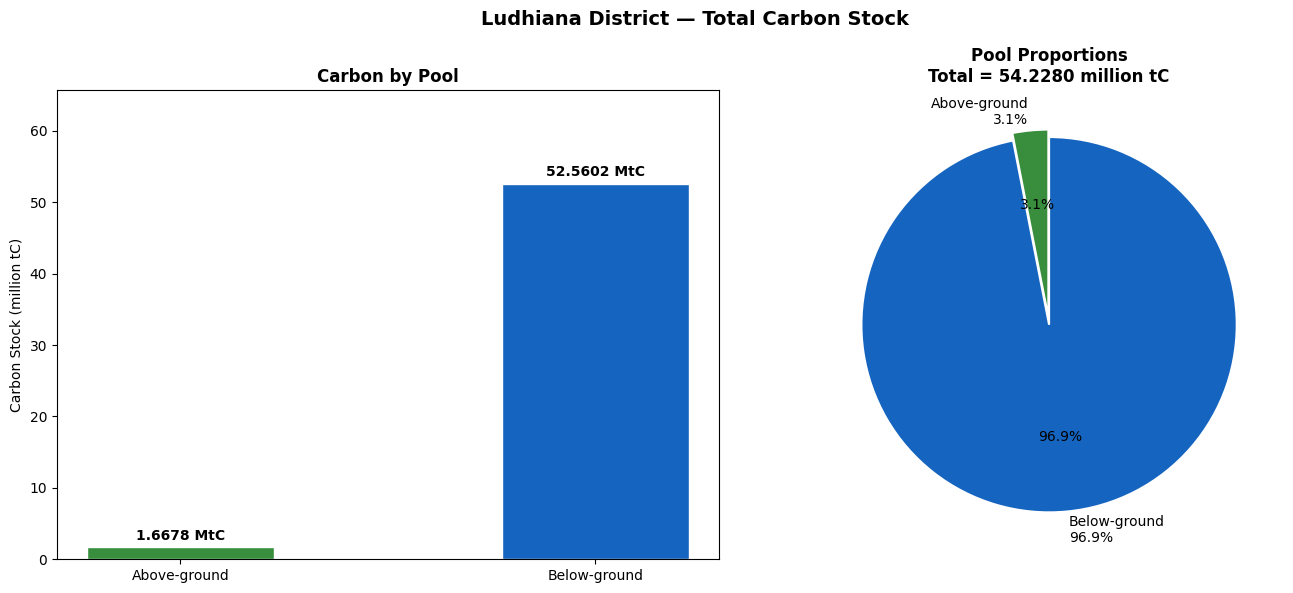

plot6 saved
LUDHIANA DISTRICT - CARBON STOCK INVENTORY

STUDY AREA
  District           : Ludhiana, Punjab, India
  Grid cell size     : 250m x 250m  =  6.25 ha per cell
  Total grid cells   : 66,790
  Agricultural cells : 50,402
  Grid-based area    : 417,438 ha  (approx. 4,168 km2)
  Official area      : 376,700 ha  (3,767 km2)

CARBON FORMULAS
  Above-ground Carbon (tC/ha) = NPP (gC/m2/yr) x 0.47 / 100
  Below-ground Carbon (tC/ha) = SOC (g/kg) x Bulk Density x 30 cm / 10

SCALING
  Above-ground : mean density x 39,082 genuine NPP cells x 6.25 ha
  Below-ground : mean density x 66,790 total cells x 6.25 ha
  Genuine NPP cells = 39,082 (77.5% of 50,402 agri cells)

CARBON DENSITY
  Above-ground mean : 6.8278 tC/ha
  Below-ground mean : 125.9115 tC/ha

DISTRICT CARBON STOCK
  -----------------------------------------------------------------
  Above-ground  :        1,667,771.32 tC  =  1.6678 million tC  (3.08%)
  Below-ground  :       52,560,180.48 tC  =  52.5602 million tC  (96.92%)


In [6]:
import os, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

FOLDER        = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
CELL_AREA_HA  = 6.25
TOTAL_CELLS   = 66790
AGRI_CELLS    = 50402
GENUINE_CELLS = round(AGRI_CELLS * 12602 / 16252)
NPP_TO_AGC    = 0.47
SOC_DEPTH_CM  = 30

X_ag_test = pd.read_csv(os.path.join(FOLDER, "ag_X_test.csv"))
y_ag_test = pd.read_csv(os.path.join(FOLDER, "ag_y_test.csv")).squeeze()
X_bg_test = pd.read_csv(os.path.join(FOLDER, "bg_X_test.csv"))
y_bg_test = pd.read_csv(os.path.join(FOLDER, "bg_y_test.csv")).squeeze()
with open(os.path.join(FOLDER, "model_ag_rf.pkl"), "rb") as f: model_ag = pickle.load(f)
with open(os.path.join(FOLDER, "model_bg_rf.pkl"), "rb") as f: model_bg = pickle.load(f)

pred_npp     = np.maximum(model_ag.predict(X_ag_test), 0)
pred_soc     = np.maximum(model_bg.predict(X_bg_test), 0)
agc_per_cell = pred_npp * NPP_TO_AGC / 100.0
bd_values    = X_bg_test["bd_gcm3"].values
bgc_per_cell = pred_soc * bd_values * SOC_DEPTH_CM / 10.0

district_agc   = agc_per_cell.mean() * GENUINE_CELLS * CELL_AREA_HA
district_bgc   = bgc_per_cell.mean() * TOTAL_CELLS   * CELL_AREA_HA
district_total = district_agc + district_bgc
agc_MtC = district_agc   / 1e6
bgc_MtC = district_bgc   / 1e6
tot_MtC = district_total / 1e6
agc_pct = district_agc   / district_total * 100
bgc_pct = district_bgc   / district_total * 100

print("=" * 50)
print(f"Above-ground Carbon : {agc_MtC:.4f} million tC  ({agc_pct:.1f}%)")
print(f"Below-ground Carbon : {bgc_MtC:.4f} million tC  ({bgc_pct:.1f}%)")
print(f"TOTAL Carbon Stock  : {tot_MtC:.4f} million tC")
print("=" * 50)

pd.DataFrame({"Predicted_NPP":np.round(pred_npp,4),"AGC_tC_ha":np.round(agc_per_cell,4),
              "True_NPP":np.round(y_ag_test.values,4)}).to_csv(
    os.path.join(FOLDER,"ag_carbon_per_cell.csv"),index=False)
pd.DataFrame({"Predicted_SOC":np.round(pred_soc,4),"BD":np.round(bd_values,4),
              "BGC_tC_ha":np.round(bgc_per_cell,4),"True_SOC":np.round(y_bg_test.values,4)}).to_csv(
    os.path.join(FOLDER,"bg_carbon_per_cell.csv"),index=False)

# Plot 5 — Carbon Stock Density Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Carbon Stock Density Distribution", fontsize=13, fontweight="bold")
for ax, data, title, color in [
    (axes[0], agc_per_cell, f"Above-ground ({len(agc_per_cell):,} cells)", "#2E7D32"),
    (axes[1], bgc_per_cell, f"Below-ground ({len(bgc_per_cell):,} cells)", "#1565C0")]:
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red", lw=2, linestyle="--",
               label=f"Mean = {data.mean():.2f} tC/ha")
    ax.axvline(float(np.median(data)), color="orange", lw=1.5, linestyle="-",
               label=f"Median = {float(np.median(data)):.2f} tC/ha")
    ax.set_xlabel("tC/ha"); ax.set_ylabel("Count")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER,"plot5_carbon_distribution.png"),dpi=150,bbox_inches="tight")
plt.show(); plt.close(); print("plot5 saved")

# Plot 6 — District Summary Bar + Pie
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ludhiana District — Total Carbon Stock", fontsize=14, fontweight="bold")
bars = axes[0].bar(["Above-ground","Below-ground"],[agc_MtC,bgc_MtC],
                   color=["#388E3C","#1565C0"],edgecolor="white",width=0.45)
axes[0].set_ylabel("Carbon Stock (million tC)")
axes[0].set_title("Carbon by Pool", fontweight="bold")
axes[0].set_ylim(0, max(agc_MtC,bgc_MtC)*1.25)
for bar, val in zip(bars, [agc_MtC, bgc_MtC]):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+max(agc_MtC,bgc_MtC)*0.02,
                 f"{val:.4f} MtC", ha="center", fontsize=10, fontweight="bold")
axes[1].pie([district_agc,district_bgc],
    labels=[f"Above-ground\n{agc_pct:.1f}%",f"Below-ground\n{bgc_pct:.1f}%"],
    colors=["#388E3C","#1565C0"],autopct="%1.1f%%",startangle=90,
    explode=(0.04,0),wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title(f"Pool Proportions\nTotal = {tot_MtC:.4f} million tC",fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FOLDER,"plot6_carbon_summary.png"),dpi=150,bbox_inches="tight")
plt.show(); plt.close(); print("plot6 saved")

# Full carbon report
sep  = "=" * 55
sep2 = "-" * 65
report = (
    f"LUDHIANA DISTRICT - CARBON STOCK INVENTORY\n{sep}\n\n"
    f"STUDY AREA\n"
    f"  District           : Ludhiana, Punjab, India\n"
    f"  Grid cell size     : 250m x 250m  =  6.25 ha per cell\n"
    f"  Total grid cells   : {TOTAL_CELLS:,}\n"
    f"  Agricultural cells : {AGRI_CELLS:,}\n"
    f"  Grid-based area    : {TOTAL_CELLS * CELL_AREA_HA:,.0f} ha  (approx. 4,168 km2)\n"
    f"  Official area      : 376,700 ha  (3,767 km2)\n\n"
    f"CARBON FORMULAS\n"
    f"  Above-ground Carbon (tC/ha) = NPP (gC/m2/yr) x 0.47 / 100\n"
    f"  Below-ground Carbon (tC/ha) = SOC (g/kg) x Bulk Density x 30 cm / 10\n\n"
    f"SCALING\n"
    f"  Above-ground : mean density x {GENUINE_CELLS:,} genuine NPP cells x {CELL_AREA_HA} ha\n"
    f"  Below-ground : mean density x {TOTAL_CELLS:,} total cells x {CELL_AREA_HA} ha\n"
    f"  Genuine NPP cells = {GENUINE_CELLS:,} ({GENUINE_CELLS/AGRI_CELLS*100:.1f}% of {AGRI_CELLS:,} agri cells)\n\n"
    f"CARBON DENSITY\n"
    f"  Above-ground mean : {agc_per_cell.mean():.4f} tC/ha\n"
    f"  Below-ground mean : {bgc_per_cell.mean():.4f} tC/ha\n\n"
    f"DISTRICT CARBON STOCK\n"
    f"  {sep2}\n"
    f"  Above-ground  :  {district_agc:>18,.2f} tC  =  {agc_MtC:.4f} million tC  ({agc_pct:.2f}%)\n"
    f"  Below-ground  :  {district_bgc:>18,.2f} tC  =  {bgc_MtC:.4f} million tC  ({bgc_pct:.2f}%)\n"
    f"  {sep2}\n"
    f"  TOTAL         :  {district_total:>18,.2f} tC  =  {tot_MtC:.4f} million tC\n"
)
with open(os.path.join(FOLDER,"carbon_final_report.txt"),"w",encoding="utf-8") as f:
    f.write(report)
print(report)
print("carbon_final_report.txt saved.  STEP 7 COMPLETE")

## Step 8 — Predict Carbon for ALL 66,790 Grid Cells

In [7]:
# ======================================================================
#  CARBON STOCK PREDICTION — ALL 66,790 GRID CELLS
#  Continues from the trained models saved in Step 5 above.
#  Produces: carbon_all_66790_final.csv + district_carbon_summary_66790.txt
# ======================================================================

import os, pickle
import numpy as np
import pandas as pd

# ── FOLDER (same as all cells above) ──────────────────────────────────
FOLDER = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"

# ── CONSTANTS ──────────────────────────────────────────────────────────
CELL_HA    = 6.25
AG_FORMULA = 0.47 / 100   # AGC (tC/ha) = NPP x 0.47 / 100
BG_FORMULA = 30 / 10      # BGC (tC/ha) = SOC x BD x 30 / 10

AG_FEATURES = [
    "DEM_mean",   "Slope_mean", "Kharif_pea",  "Kharif_Pre",
    "LST_Sept20", "Rabi_LST_2", "Rabi_Peak_",  "Rabi_Preci",
    "Kharif_Lud", "NDWI_Rabi_",
    "NDVI_Jun24", "NDVI_Jul24", "NDVI_Aug24",  "NDVI_Sep24",
    "NDVI_Oct24", "NDVI_Nov24", "NDVI_Dec24",  "NDVI_Jan25",
    "NDVI_Feb25", "NDVI_Mar25", "NDVI_Apr25",  "NDVI_May25",
]
BG_FEATURES = ["agri_class","DEM_mean","Slope_mean","sand_pct","clay_pct","bd_gcm3"]
NDVI_COLS   = [
    "NDVI_Jun24","NDVI_Jul24","NDVI_Aug24","NDVI_Sep24",
    "NDVI_Oct24","NDVI_Nov24","NDVI_Dec24","NDVI_Jan25",
    "NDVI_Feb25","NDVI_Mar25","NDVI_Apr25","NDVI_May25",
]

print("=" * 65)
print("  CARBON STOCK PIPELINE -- ALL 66,790 GRID CELLS")
print("=" * 65)

# ── [1/7] LOAD MODELS ─────────────────────────────────────────────────
# Using Random Forest models (best R2 in evaluation above)
# To use XGBoost instead, change _rf to _xgb in the filenames below
print("\n[1/7] Loading trained models...")
with open(os.path.join(FOLDER, "model_ag_rf.pkl"), "rb") as f:
    model_ag = pickle.load(f)
with open(os.path.join(FOLDER, "model_bg_rf.pkl"), "rb") as f:
    model_bg = pickle.load(f)
print(f"    AG model: {type(model_ag).__name__}")
print(f"    BG model: {type(model_bg).__name__}")

# ── [2/7] LOAD DATA FILES ─────────────────────────────────────────────
print("\n[2/7] Loading input data files...")

# All 66k files — note the exact filenames with parentheses
agd_all   = pd.read_csv(os.path.join(FOLDER, "AGD_for_all_grids_geom.csv"))
bgd_all   = pd.read_csv(os.path.join(FOLDER, "BGD_for_all_grids(GEOM).csv"))
ndvi_66k  = pd.read_csv(os.path.join(FOLDER, "ndvi_monthly_ludhiana_all_66790.csv"))
ndvi_20k  = pd.read_csv(os.path.join(FOLDER, "ndvi_monthly_ludhiana_jun24_may25.csv"))
ag_geom20 = pd.read_csv(os.path.join(FOLDER, "Above_ground_data_geom.csv"))
bg_geom20 = pd.read_csv(os.path.join(FOLDER, "Below_Ground_Data_geom.csv"))

# Deduplicate — 2,155 Grid_IDs appear twice with different locations (GEE artifact)
# Keep the row with highest Ag/NonAg_m (most agricultural version of each cell)
agd_all   = agd_all.sort_values("Ag/NonAg_m", ascending=False).drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)
bgd_all   = bgd_all.sort_values("Ag/NonAg_m", ascending=False).drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)
ndvi_66k  = ndvi_66k.drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)
ndvi_20k  = ndvi_20k.drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)
ag_geom20 = ag_geom20.drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)
bg_geom20 = bg_geom20.drop_duplicates(subset="Grid_ID", keep="first").reset_index(drop=True)

print(f"    AGD: {len(agd_all):,} rows | BGD: {len(bgd_all):,} rows | NDVI 66k: {len(ndvi_66k):,} rows")
print(f"    (2,155 duplicate Grid_IDs resolved)")

# ── [3/7] FIX COLUMN NAME MISMATCHES ─────────────────────────────────
print("\n[3/7] Fixing column name mismatches...")

# BGD: BD_g_cm3 -> bd_gcm3 (model was trained with lowercase name)
bgd_all = bgd_all.rename(columns={"BD_g_cm3": "bd_gcm3"})

# AGD: three columns have different names in the 66k export vs model training
agd_all = agd_all.rename(columns={
    "Kharif_Pea": "Kharif_pea",   # uppercase P -> lowercase p
    "Rabi Peak":  "Rabi_Peak_",   # space -> underscore
    "NDWI_Khari": "Kharif_Lud",   # alias confirmed in project notes
})
print("    3 AG columns renamed, 1 BG column renamed ✓")

# ── [4/7] PREPARE NDVI — FILL MISSING VALUES ─────────────────────────
# NDVI_Aug24 is missing in ~48% of cells (peak monsoon cloud cover)
# Strategy: use 20k values where available (zero missing), then median
print("\n[4/7] Preparing NDVI — filling missing values...")
print(f"    NDVI_Jul24 missing: {ndvi_66k['NDVI_Jul24'].isna().sum():,}")
print(f"    NDVI_Aug24 missing: {ndvi_66k['NDVI_Aug24'].isna().sum():,}")

ndvi_filled = ndvi_66k.set_index("Grid_ID")
ndvi_filled.update(ndvi_20k.set_index("Grid_ID")[NDVI_COLS])  # override with 20k quality
ndvi_filled = ndvi_filled.reset_index()

for col in NDVI_COLS:
    n = ndvi_filled[col].isna().sum()
    if n > 0:
        med = ndvi_filled[col].median()
        ndvi_filled[col] = ndvi_filled[col].fillna(med)
        print(f"    {col}: filled {n:,} with median={med:.4f}")

assert ndvi_filled[NDVI_COLS].isna().sum().sum() == 0, "NDVI still has NaN!"
print("    All NDVI missing values resolved ✓")

# ── [5/7] BG PREDICTIONS — ALL CELLS ─────────────────────────────────
print("\n[5/7] Running BG predictions (all cells)...")

ids_20k_bg = set(bg_geom20["Grid_ID"])
bgd_all["source"] = bgd_all["Grid_ID"].apply(
    lambda x: "20k_repredicted" if x in ids_20k_bg else "new_prediction")

pred_soc = np.clip(model_bg.predict(bgd_all[BG_FEATURES]), 0, None)
bgc_tha  = pred_soc * bgd_all["bd_gcm3"].values * BG_FORMULA
bgd_all["Predicted_SOC"] = pred_soc
bgd_all["BGC_tC_ha"]     = bgc_tha

print(f"    {len(bgd_all):,} cells predicted")
print(f"    BGC mean: {bgc_tha.mean():.4f} tC/ha   Total: {bgc_tha.sum()*CELL_HA/1e6:.4f} million tC")

# ── [6/7] AG PREDICTIONS — AGRICULTURAL CELLS ONLY ───────────────────
print("\n[6/7] Running AG predictions (agricultural cells only)...")

# Merge NDVI into AGD
agd_full = agd_all.merge(ndvi_filled[["Grid_ID"] + NDVI_COLS], on="Grid_ID", how="left")
assert len(agd_full) == len(agd_all), "Row count changed after NDVI merge!"

missing_feats = [f for f in AG_FEATURES if f not in agd_full.columns]
if missing_feats:
    raise ValueError(f"Missing AG features: {missing_feats}")
print(f"    All 22 AG features confirmed ✓")

# Split agri vs non-agri
agd_agri  = agd_full[agd_full["agri_class"] == 1].copy().reset_index(drop=True)
agd_nonag = agd_full[agd_full["agri_class"] == 0][["Grid_ID"]].copy()
print(f"    Agricultural cells: {len(agd_agri):,}  |  Non-agricultural: {len(agd_nonag):,}")

# Predict NPP on agri cells, convert to AGC
pred_npp = np.clip(model_ag.predict(agd_agri[AG_FEATURES]), 0, None)
agc_tha  = pred_npp * AG_FORMULA
agd_agri["Predicted_NPP"] = pred_npp
agd_agri["AGC_tC_ha"]     = agc_tha

ids_20k_ag = set(ag_geom20["Grid_ID"])
agd_agri["source"] = agd_agri["Grid_ID"].apply(
    lambda x: "20k_repredicted" if x in ids_20k_ag else "new_prediction")

# Non-agri gets AGC = 0
agd_nonag = agd_nonag.assign(Predicted_NPP=0.0, AGC_tC_ha=0.0, source="non_agricultural")
ag_out = pd.concat([agd_agri, agd_nonag], ignore_index=True)

print(f"    AGC mean (agri): {agc_tha.mean():.4f} tC/ha   Total: {agc_tha.sum()*CELL_HA/1e6:.4f} million tC")

# ── [7/7] MERGE + FINAL OUTPUT ────────────────────────────────────────
print("\n[7/7] Building final output table...")

bg_keep = ["Grid_ID","WKT","Ag/NonAg_m","agri_class","DEM_mean","Slope_mean",
           "sand_pct","clay_pct","bd_gcm3","Predicted_SOC","BGC_tC_ha"]
ag_keep = ["Grid_ID","Predicted_NPP","AGC_tC_ha","source"]

final = bgd_all[bg_keep].merge(ag_out[ag_keep], on="Grid_ID", how="left")
final["AGC_tC_ha"]        = final["AGC_tC_ha"].fillna(0.0)
final["Predicted_NPP"]    = final["Predicted_NPP"].fillna(0.0)
final["Total_C_tC_ha"]    = final["AGC_tC_ha"] + final["BGC_tC_ha"]
final["Total_CO2e_tC_ha"] = final["Total_C_tC_ha"] * (44 / 12)  # IPCC conversion

print(f"    Final table: {final.shape[0]:,} rows x {final.shape[1]} columns")

# District totals
t_ag  = final["AGC_tC_ha"].sum() * CELL_HA
t_bg  = final["BGC_tC_ha"].sum() * CELL_HA
t_all = t_ag + t_bg
t_co2 = t_all * (44 / 12)

summary = f"""
LUDHIANA DISTRICT — UPDATED CARBON STOCK INVENTORY (66,790 Grid Cells)
=======================================================================

GRID CELL BREAKDOWN
  Total unique cells         : {len(final):,}
  Agricultural (agri=1)      : {(final['agri_class']==1).sum():,}
  Non-agricultural (agri=0)  : {(final['agri_class']==0).sum():,}
  Cell area                  : {CELL_HA} ha
  Note: 2,155 duplicate Grid_IDs resolved (kept highest Ag/NonAg_m)

PREDICTION SOURCE
  20k cells (re-predicted)   : {(final['source']=='20k_repredicted').sum():,}
  New cells (fresh predict)  : {(final['source']=='new_prediction').sum():,}
  Non-agricultural (AGC=0)   : {(final['source']=='non_agricultural').sum():,}

CARBON DENSITY (mean)
  Above-ground (agri cells)  : {final.loc[final['agri_class']==1,'AGC_tC_ha'].mean():.4f} tC/ha
  Below-ground (all cells)   : {final['BGC_tC_ha'].mean():.4f} tC/ha

DISTRICT CARBON STOCK
  -------------------------------------------------------------------
  Above-ground : {t_ag:>22,.2f} tC  =  {t_ag/1e6:.4f} million tC  ({100*t_ag/t_all:.2f}%)
  Below-ground : {t_bg:>22,.2f} tC  =  {t_bg/1e6:.4f} million tC  ({100*t_bg/t_all:.2f}%)
  -------------------------------------------------------------------
  TOTAL        : {t_all:>22,.2f} tC  =  {t_all/1e6:.4f} million tC

CO2 EQUIVALENT (x 3.667)
  Total CO2e   : {t_co2/1e6:.4f} million tCO2e
"""

print(summary)

# Save outputs
final.to_csv(os.path.join(FOLDER, "carbon_all_66790_final.csv"), index=False)
with open(os.path.join(FOLDER, "district_carbon_summary_66790.txt"), "w") as f:
    f.write(summary)

print(f"  Saved: carbon_all_66790_final.csv  ({len(final):,} rows)")
print(f"  Saved: district_carbon_summary_66790.txt")
print("\n" + "=" * 65)
print("  STEP 8 COMPLETE — ALL 66,790 CELLS PREDICTED")
print("=" * 65)

  CARBON STOCK PIPELINE -- ALL 66,790 GRID CELLS

[1/7] Loading trained models...
    AG model: RandomForestRegressor
    BG model: RandomForestRegressor

[2/7] Loading input data files...
    AGD: 64,545 rows | BGD: 64,545 rows | NDVI 66k: 64,545 rows
    (2,155 duplicate Grid_IDs resolved)

[3/7] Fixing column name mismatches...
    3 AG columns renamed, 1 BG column renamed ✓

[4/7] Preparing NDVI — filling missing values...
    NDVI_Jul24 missing: 3,588
    NDVI_Aug24 missing: 31,396
    NDVI_Jul24: filled 2,554 with median=0.3093
    NDVI_Aug24: filled 21,723 with median=0.7899
    All NDVI missing values resolved ✓

[5/7] Running BG predictions (all cells)...
    64,545 cells predicted
    BGC mean: 126.1101 tC/ha   Total: 50.8736 million tC

[6/7] Running AG predictions (agricultural cells only)...
    All 22 AG features confirmed ✓
    Agricultural cells: 52,809  |  Non-agricultural: 11,736
    AGC mean (agri): 6.1697 tC/ha   Total: 2.0363 million tC

[7/7] Building final output

## STEP 8A : SAVE TO MONGODB (Local)

In [8]:
from pymongo import MongoClient
from datetime import date
import os, pandas as pd

FOLDER = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"

ag_res = pd.read_csv(os.path.join(FOLDER, "ag_carbon_per_cell.csv"))
bg_res = pd.read_csv(os.path.join(FOLDER, "bg_carbon_per_cell.csv"))

client = MongoClient("mongodb://localhost:27017/")
db     = client["carbon_stock_ludhiana"]

# ── AG predictions → own collection (2,521 records) ──────────────────
ag_records = []
for i in range(len(ag_res)):
    ag_records.append({
        "grid_index"    : int(i),
        "run_date"      : str(date.today()),
        "pool"          : "above_ground",
        "predicted_npp" : float(ag_res["Predicted_NPP"].iloc[i]),
        "agc_tC_ha"     : float(ag_res["AGC_tC_ha"].iloc[i]),
        "true_npp"      : float(ag_res["True_NPP"].iloc[i]),
    })

# ── BG predictions → own collection (4,000 records) ──────────────────
bg_records = []
for i in range(len(bg_res)):
    bg_records.append({
        "grid_index"    : int(i),
        "run_date"      : str(date.today()),
        "pool"          : "below_ground",
        "predicted_soc" : float(bg_res["Predicted_SOC"].iloc[i]),
        "bd_gcm3"       : float(bg_res["BD"].iloc[i]),
        "bgc_tC_ha"     : float(bg_res["BGC_tC_ha"].iloc[i]),
        "true_soc"      : float(bg_res["True_SOC"].iloc[i]),
    })

# ── Insert into separate collections ─────────────────────────────────
db["ag_predictions"].drop()   # clear old data if re-running
db["bg_predictions"].drop()

db["ag_predictions"].insert_many(ag_records)
db["bg_predictions"].insert_many(bg_records)

print(f"Pushed {len(ag_records):,} records to 'ag_predictions'")
print(f"Pushed {len(bg_records):,} records to 'bg_predictions'")
print("Database: carbon_stock_ludhiana")

Pushed 2,521 records to 'ag_predictions'
Pushed 4,000 records to 'bg_predictions'
Database: carbon_stock_ludhiana


## STEP 8B : SAVE TO POSTGRESQL

In [9]:
import psycopg2
from datetime import date
import os, pandas as pd

FOLDER      = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"
PG_PASSWORD = "Sathvik@6"   # <- YOUR PGADMIN PASSWORD

ag_res = pd.read_csv(os.path.join(FOLDER, "ag_carbon_per_cell.csv"))
bg_res = pd.read_csv(os.path.join(FOLDER, "bg_carbon_per_cell.csv"))

CELL_AREA_HA  = 6.25
TOTAL_CELLS   = 66790
AGRI_CELLS    = 50402
GENUINE_CELLS = round(AGRI_CELLS * 12602 / 16252)

agc_MtC = ag_res["AGC_tC_ha"].mean() * GENUINE_CELLS * CELL_AREA_HA / 1e6
bgc_MtC = bg_res["BGC_tC_ha"].mean() * TOTAL_CELLS   * CELL_AREA_HA / 1e6
tot_MtC = agc_MtC + bgc_MtC
agc_pct = agc_MtC / tot_MtC * 100
bgc_pct = bgc_MtC / tot_MtC * 100

conn = psycopg2.connect(host="localhost", database="postgres",
                        user="postgres", password=PG_PASSWORD)
cur  = conn.cursor()

cur.execute("""
    INSERT INTO district_summary
    (run_date, ag_model, bg_model, ag_r2, bg_r2, ag_rmse, bg_rmse,
     agc_million_tC, bgc_million_tC, total_million_tC, agc_pct, bgc_pct)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", (str(date.today()),
      "Random Forest", "Random Forest",
      float(0.5426), float(0.9665), float(448.597), float(1.392),
      float(round(agc_MtC,4)), float(round(bgc_MtC,4)), float(round(tot_MtC,4)),
      float(round(agc_pct,2)), float(round(bgc_pct,2))))

conn.commit(); cur.close(); conn.close()
print("Data saved to PostgreSQL successfully")
print(f"AGC={agc_MtC:.4f} MtC  BGC={bgc_MtC:.4f} MtC  Total={tot_MtC:.4f} MtC")

Data saved to PostgreSQL successfully
AGC=1.6678 MtC  BGC=52.5602 MtC  Total=54.2280 MtC


In [10]:
# In a new notebook cell or script
# Load carbon_all_66790_final.csv and insert into MongoDB

import pandas as pd
from pymongo import MongoClient

final = pd.read_csv(r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks\carbon_all_66790_final.csv")
client = MongoClient("mongodb://localhost:27017/")
db = client["carbon_stock_ludhiana"]
db["all_predictions"].drop()
db["all_predictions"].insert_many(final.to_dict(orient="records"))
print(f"Inserted {len(final):,} records")

# Then tell me and I will update the website to use `all_predictions` instead of the test-set-only collections.


"""
## Phase 4 — Presentation Preparation

For your BDA project submission you will need:

**Screenshots to take now while the website looks good:**
- Home page with all 6 KPI cards
- Map page zoomed to level 13–14 showing the grid
- Map page with Dark basemap
- Analytics page showing all charts
- Model page showing the R² ring gauges
- Explorer page with the table

**Documents to export from your notebook:**
- `carbon_final_report.txt` — already exists
- `evaluation_report.txt` — already exists
- The 6 plot PNG files — already exist

**What to explain in your presentation:**
The website connects PostGIS (spatial geometry of 66,790 grid cells), MongoDB (Random Forest predictions), and Leaflet.js (interactive map) into one integrated dashboard — which is the core of your BDA project.

---

## Summary — Your Priority Order
```
1. Run Cell 15 in notebook  → generates carbon_all_66790_final.csv
2. Run Cell 17              → fills MongoDB with real predictions
3. Run Cell 19              → fills PostgreSQL district_summary
4. Restart Flask server     → website shows live data
5. Insert all_66790 data    → map shows full district coverage
6. Take screenshots         → for presentation
"""

Inserted 64,545 records


'\n## Phase 4 — Presentation Preparation\n\nFor your BDA project submission you will need:\n\n**Screenshots to take now while the website looks good:**\n- Home page with all 6 KPI cards\n- Map page zoomed to level 13–14 showing the grid\n- Map page with Dark basemap\n- Analytics page showing all charts\n- Model page showing the R² ring gauges\n- Explorer page with the table\n\n**Documents to export from your notebook:**\n- `carbon_final_report.txt` — already exists\n- `evaluation_report.txt` — already exists\n- The 6 plot PNG files — already exist\n\n**What to explain in your presentation:**\nThe website connects PostGIS (spatial geometry of 66,790 grid cells), MongoDB (Random Forest predictions), and Leaflet.js (interactive map) into one integrated dashboard — which is the core of your BDA project.\n\n---\n\n## Summary — Your Priority Order\n```\n1. Run Cell 15 in notebook  → generates carbon_all_66790_final.csv\n2. Run Cell 17              → fills MongoDB with real predictions\n3. Ru

In [11]:
from pymongo import MongoClient
from urllib.parse import quote_plus

# Your Atlas credentials
USERNAME = "sathvik_BDA_project"
PASSWORD = "upUjc0w06guetqnP"

# Connect to local MongoDB
local = MongoClient("mongodb://localhost:27017/")["carbon_stock_ludhiana"]

# Connect to Atlas
ATLAS_URI = (
    "mongodb+srv://" + quote_plus(USERNAME) +
    ":" + quote_plus(PASSWORD) +
    "@cluster0.2ioxhyq.mongodb.net/?appName=Cluster0"
)
atlas = MongoClient(ATLAS_URI)["carbon_stock_ludhiana"]

# Collections to sync
collections = [
    "all_predictions",
    "ag_predictions",
    "bg_predictions",
    "ndvi_summary",
    "model_metadata",
]

for name in collections:
    docs = list(local[name].find({}, {"_id": 0}))
    if docs:
        # Clear old data first
        atlas[name].drop()
        # Insert fresh data
        atlas[name].insert_many(docs)
        print(f"✓ {name}: {len(docs):,} documents uploaded")
    else:
        print(f"✗ {name}: empty — skipped")

print("\nAll done! Atlas is now up to date.")

✓ all_predictions: 64,545 documents uploaded
✓ ag_predictions: 2,521 documents uploaded
✓ bg_predictions: 4,000 documents uploaded
✓ ndvi_summary: 12 documents uploaded
✓ model_metadata: 1 documents uploaded

All done! Atlas is now up to date.


In [12]:
import psycopg2
import psycopg2.extras
import pandas as pd
import os

FOLDER = r"C:\BDA PROJECT\.venv\IIRS\Carbon_Stocks"

print("Loading BGD file...")
bgd = pd.read_csv(os.path.join(FOLDER, "BGD_for_all_grids(GEOM).csv"))
bgd = (bgd.sort_values("Ag/NonAg_m", ascending=False)
          .drop_duplicates(subset="Grid_ID", keep="first")
          .reset_index(drop=True))
print(f"Rows after dedup: {len(bgd):,}")

print("Connecting to Supabase...")
conn = psycopg2.connect(
    host="aws-1-ap-south-1.pooler.supabase.com",
    port=5432,
    database="postgres",
    user="postgres.dexguularfuqzkqmcjnc",
    password="CarbonStock@2025",
    sslmode="require"
)
conn.autocommit = False
cur = conn.cursor()
print("Connected successfully!")

# Clear existing data
cur.execute("TRUNCATE grid_cells RESTART IDENTITY;")

batch = []
total = len(bgd)
inserted = 0

for i, row in bgd.iterrows():
    batch.append((
        int(row["Grid_ID"]),
        str(row["WKT"]),
        int(row["agri_class"]),
        float(row["Ag/NonAg_m"]),
        float(row["DEM_mean"]   or 0),
        float(row["Slope_mean"] or 0),
        float(row.get("sand_pct", 0) or 0),
        float(row.get("clay_pct", 0) or 0),
        float(row.get("BD_g_cm3", 1.5) or 1.5),
    ))

    if len(batch) == 500:
        psycopg2.extras.execute_batch(cur, """
            INSERT INTO grid_cells
            (grid_id, geom, agri_class, agnonag_m,
             dem_mean, slope_mean, sand_pct, clay_pct, bd_gcm3)
            VALUES (%s, ST_GeomFromText(%s, 4326),
                    %s, %s, %s, %s, %s, %s, %s)
        """, batch)
        conn.commit()
        inserted += len(batch)
        batch = []
        pct = int(inserted / total * 100)
        print(f"Progress: {pct}% ({inserted:,} / {total:,})", end="\r")

# Insert remaining rows
if batch:
    psycopg2.extras.execute_batch(cur, """
        INSERT INTO grid_cells
        (grid_id, geom, agri_class, agnonag_m,
         dem_mean, slope_mean, sand_pct, clay_pct, bd_gcm3)
        VALUES (%s, ST_GeomFromText(%s, 4326),
                %s, %s, %s, %s, %s, %s, %s)
    """, batch)
    conn.commit()
    inserted += len(batch)

cur.close()
conn.close()
print(f"\nDone! Uploaded {inserted:,} grid cells to Supabase.")


Loading BGD file...
Rows after dedup: 64,545
Connecting to Supabase...
Connected successfully!
Progress: 99% (64,500 / 64,545)
Done! Uploaded 64,545 grid cells to Supabase.
